In [150]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

# Visualization settings - FIXED
plt.style.use('seaborn-v0_8-whitegrid')  # Was: 'seaborn- v8_whitergrid'
sns.set_palette("husl")
pd.set_option('display.max_columns', None)


In [151]:
df = pd.read_csv("/content/segmentation data.csv")

print("="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\n" + "="*60)
print("DATA INFORMATION")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("DUPLICATE CHECK")
print("="*60)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Drop ID column (not useful for clustering)
df_clean = df.drop('ID', axis=1)
print(f"\nDataset shape after dropping ID: {df_clean.shape}")
print("\nFirst 5 rows after dropping ID:")
print(df_clean.head())

DATA OVERVIEW
Dataset shape: (2000, 8)

First 5 rows:
          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  

DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null  

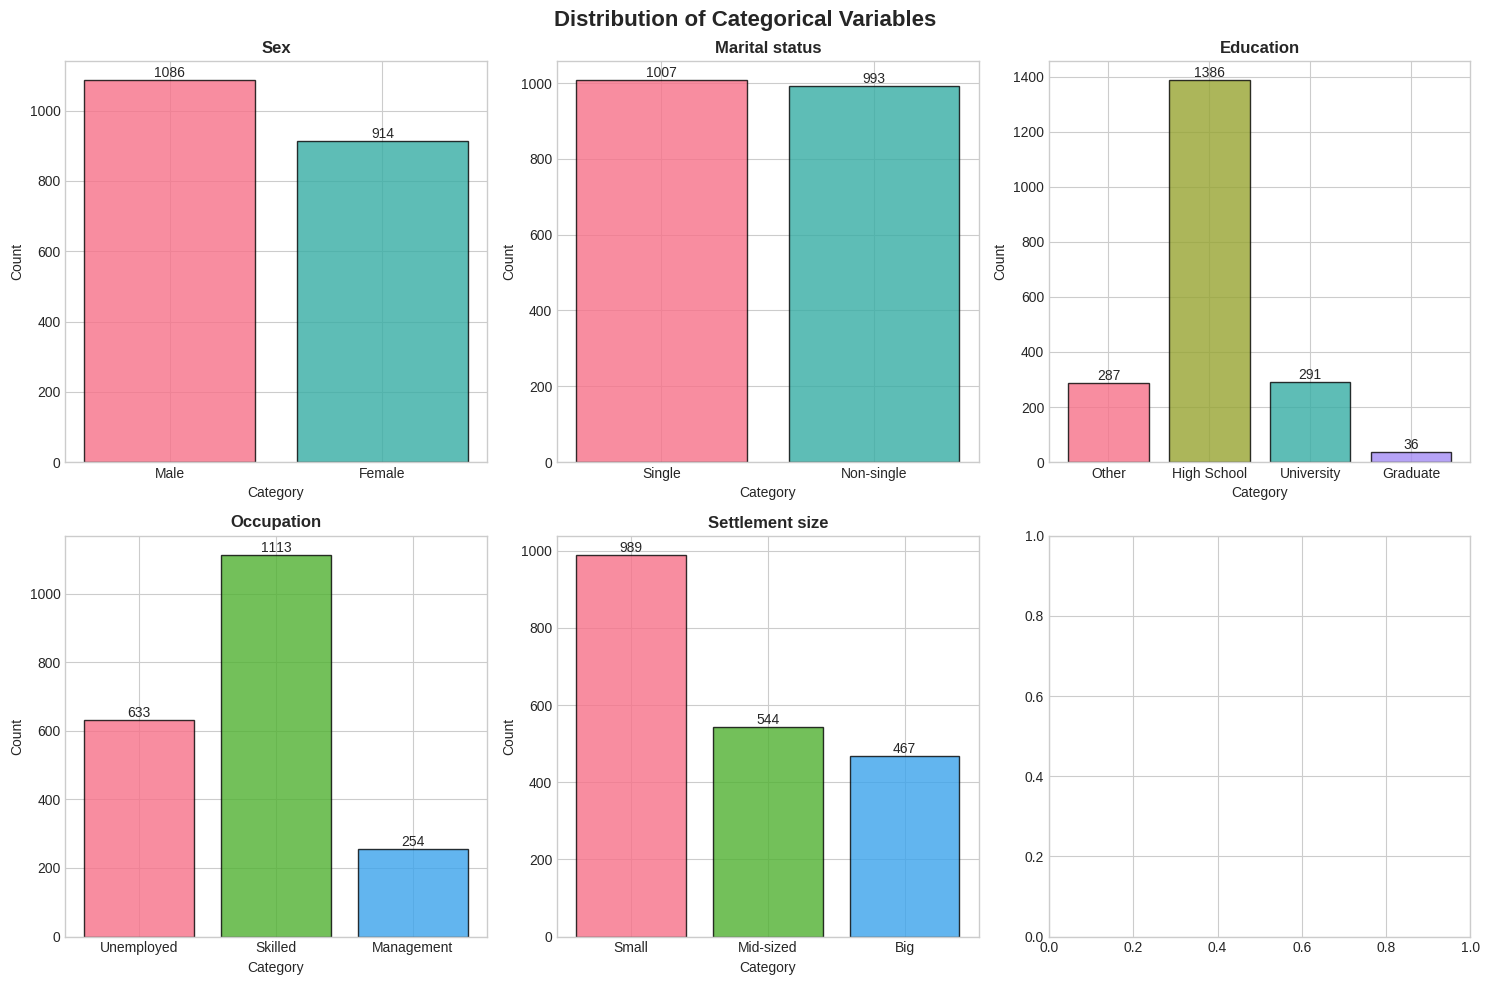

In [152]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16, fontweight='bold')  # FIXED: was fig.subtitle

categorical_cols = ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']
labels_dict = {
    'Sex': ['Male', 'Female'],
    'Marital status': ['Single', 'Non-single'],
    'Education': ['Other', 'High School', 'University', 'Graduate'],
    'Occupation': ['Unemployed', 'Skilled', 'Management'],
    'Settlement size': ['Small', 'Mid-sized', 'Big']
}

for idx, col in enumerate(categorical_cols):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row, col_idx]

    counts = df_clean[col].value_counts().sort_index()
    colors = sns.color_palette("husl", len(counts))
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10)

    if col in labels_dict:
        ax.set_xticks(range(len(labels_dict[col])))
        ax.set_xticklabels(labels_dict[col], rotation=0)

plt.tight_layout()
plt.show()

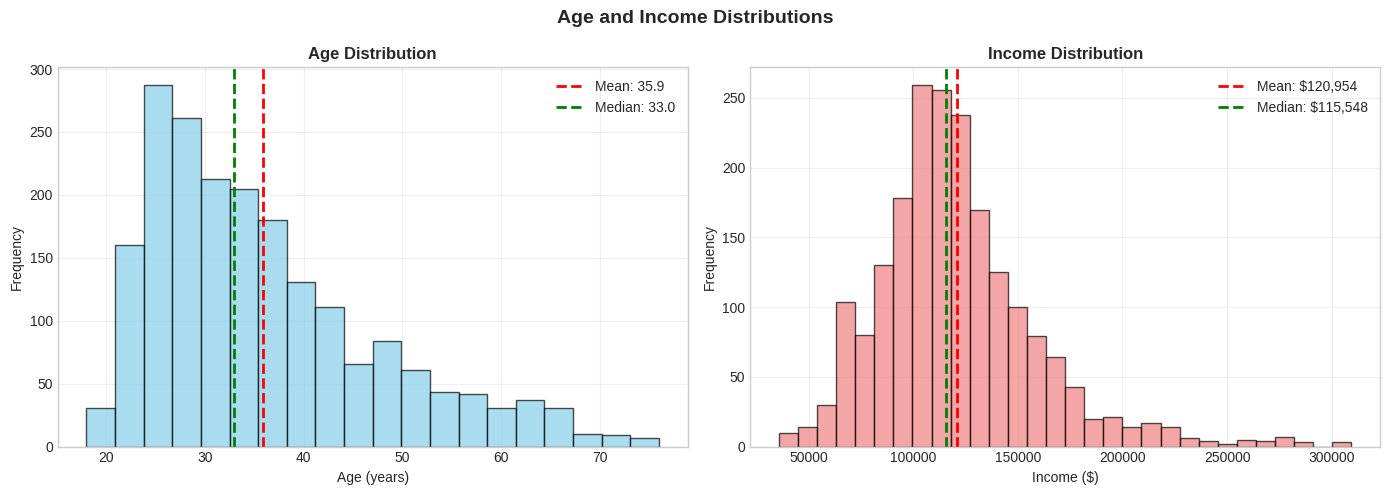

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age and Income Distributions', fontsize=14, fontweight='bold')

# Age distribution
axes[0].hist(df_clean['Age'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(df_clean['Age'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df_clean["Age"].mean():.1f}')
axes[0].axvline(df_clean['Age'].median(), color='green', linestyle='--', linewidth=2,
                label=f'Median: {df_clean["Age"].median():.1f}')
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Income distribution
axes[1].hist(df_clean['Income'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(df_clean['Income'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: ${df_clean["Income"].mean():,.0f}')
axes[1].axvline(df_clean['Income'].median(), color='green', linestyle='--', linewidth=2,
                label=f'Median: ${df_clean["Income"].median():,.0f}')
axes[1].set_title('Income Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Income ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

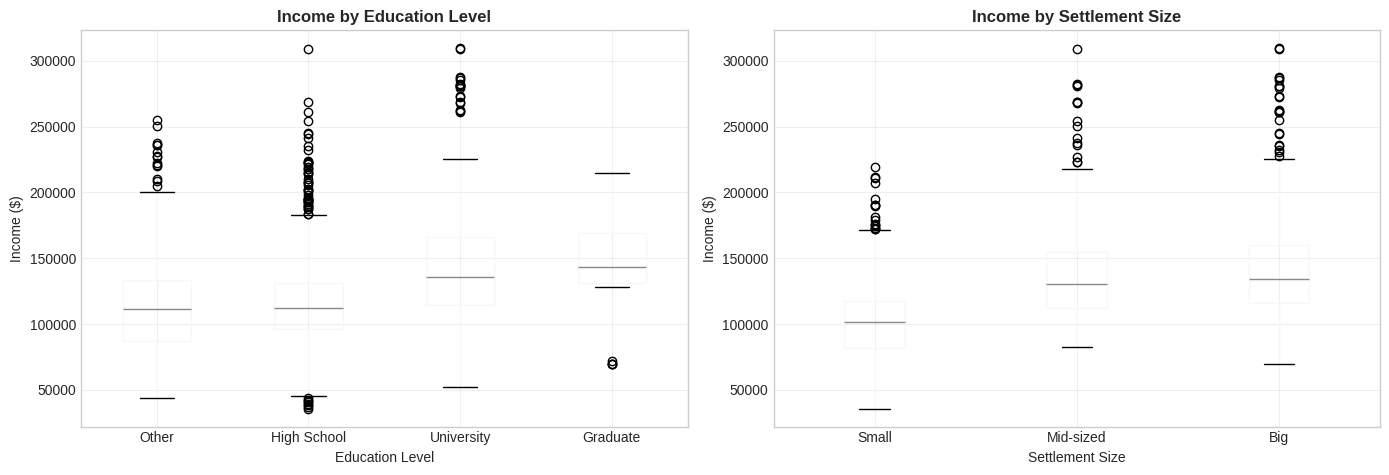

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Income Distribution by Key Variables', fontsize=14, fontweight='bold')

# Income by Education
df_clean.boxplot(column='Income', by='Education', ax=axes[0])
axes[0].set_title('Income by Education Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Income ($)')
axes[0].set_xticklabels(['Other', 'High School', 'University', 'Graduate'])
axes[0].grid(True, alpha=0.3)

# Income by Settlement Size
df_clean.boxplot(column='Income', by='Settlement size', ax=axes[1])
axes[1].set_title('Income by Settlement Size', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Settlement Size')
axes[1].set_ylabel('Income ($)')
axes[1].set_xticklabels(['Small', 'Mid-sized', 'Big'])
axes[1].grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

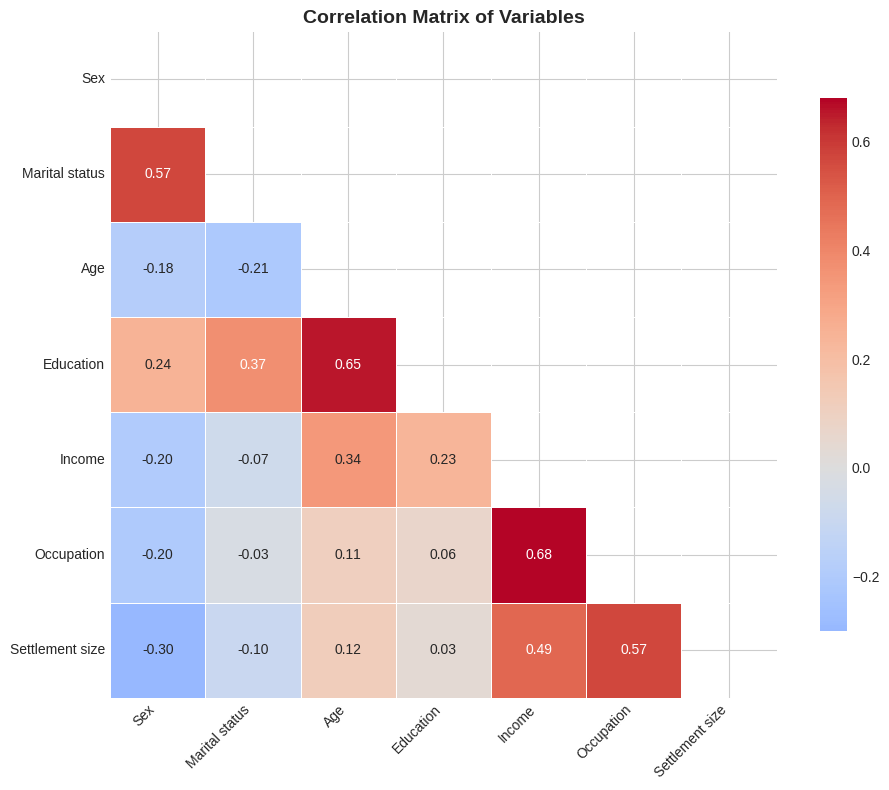

In [155]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})  # FIXED: was cbar_kwss
plt.title('Correlation Matrix of Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

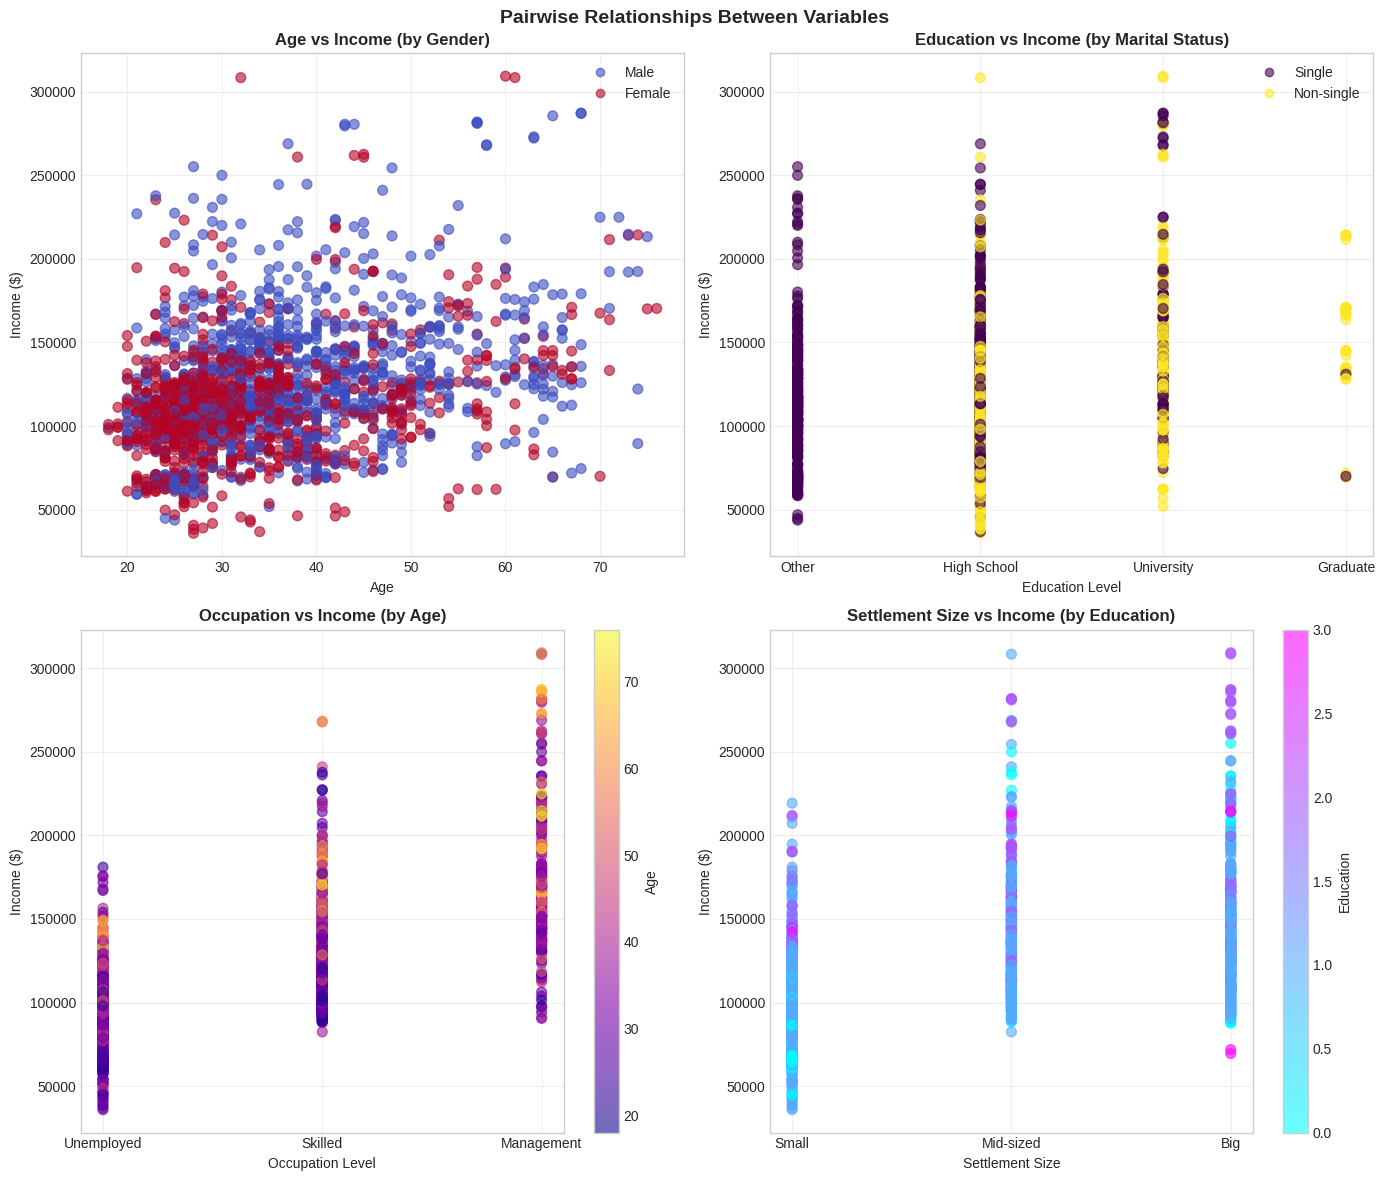

In [156]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Pairwise Relationships Between Variables', fontsize=14, fontweight='bold')

# Age vs Income
scatter1 = axes[0, 0].scatter(df_clean['Age'], df_clean['Income'],
                              c=df_clean['Sex'], cmap='coolwarm', alpha=0.6, s=50)
axes[0, 0].set_title('Age vs Income (by Gender)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Income ($)')
axes[0, 0].legend(handles=scatter1.legend_elements()[0], labels=['Male', 'Female'])
axes[0, 0].grid(True, alpha=0.3)

# Education vs Income
scatter2 = axes[0, 1].scatter(df_clean['Education'], df_clean['Income'],
                              c=df_clean['Marital status'], cmap='viridis', alpha=0.6, s=50)
axes[0, 1].set_title('Education vs Income (by Marital Status)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Education Level')
axes[0, 1].set_ylabel('Income ($)')
axes[0, 1].set_xticks([0, 1, 2, 3])
axes[0, 1].set_xticklabels(['Other', 'High School', 'University', 'Graduate'])
axes[0, 1].legend(handles=scatter2.legend_elements()[0], labels=['Single', 'Non-single'])
axes[0, 1].grid(True, alpha=0.3)

# Occupation vs Income
scatter3 = axes[1, 0].scatter(df_clean['Occupation'], df_clean['Income'],
                              c=df_clean['Age'], cmap='plasma', alpha=0.6, s=50)
axes[1, 0].set_title('Occupation vs Income (by Age)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Occupation Level')
axes[1, 0].set_ylabel('Income ($)')
axes[1, 0].set_xticks([0, 1, 2])
axes[1, 0].set_xticklabels(['Unemployed', 'Skilled', 'Management'])
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='Age')

# Settlement Size vs Income
scatter4 = axes[1, 1].scatter(df_clean['Settlement size'], df_clean['Income'],
                              c=df_clean['Education'], cmap='cool', alpha=0.6, s=50)
axes[1, 1].set_title('Settlement Size vs Income (by Education)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Settlement Size')
axes[1, 1].set_ylabel('Income ($)')
axes[1, 1].set_xticks([0, 1, 2])
axes[1, 1].set_xticklabels(['Small', 'Mid-sized', 'Big'])
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=axes[1, 1], label='Education')

plt.tight_layout()
plt.show()


STANDARDIZED DATA SUMMARY
                Sex  Marital status           Age     Education        Income  \
count  2.000000e+03    2.000000e+03  2.000000e+03  2.000000e+03  2.000000e+03   
mean  -1.421085e-16    5.684342e-17  9.059420e-17 -5.684342e-17  1.563194e-16   
std    1.000250e+00    1.000250e+00  1.000250e+00  1.000250e+00  1.000250e+00   
min   -9.173988e-01   -9.930243e-01 -1.528532e+00 -1.731068e+00 -2.234225e+00   
25%   -9.173988e-01   -9.930243e-01 -7.603825e-01 -6.337243e-02 -6.113281e-01   
50%   -9.173988e-01   -9.930243e-01 -2.482829e-01 -6.337243e-02 -1.418903e-01   
75%    1.090038e+00    1.007025e+00  5.198664e-01 -6.337243e-02  4.492952e-01   
max    1.090038e+00    1.007025e+00  3.421764e+00  3.272018e+00  4.945225e+00   

         Occupation  Settlement size  
count  2.000000e+03      2000.000000  
mean   2.842171e-17         0.000000  
std    1.000250e+00         1.000250  
min   -1.269525e+00        -0.909730  
25%   -1.269525e+00        -0.909730  
50%    2.

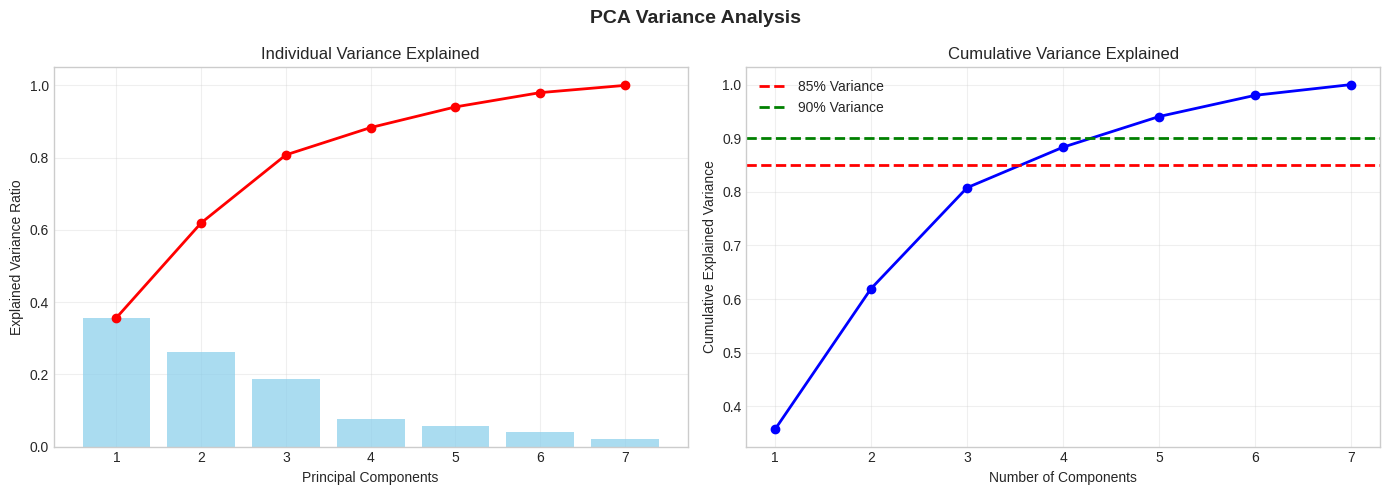


PCA VARIANCE EXPLAINED
PC1: 35.70% (Cumulative: 35.70%)
PC2: 26.25% (Cumulative: 61.95%)
PC3: 18.82% (Cumulative: 80.77%)
PC4: 7.56% (Cumulative: 88.33%)
PC5: 5.72% (Cumulative: 94.04%)
PC6: 3.95% (Cumulative: 98.00%)
PC7: 2.00% (Cumulative: 100.00%)

Recommended number of components: 5 (covers 94.04% variance)


In [157]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_clean.columns)

print("\n" + "="*60)
print("STANDARDIZED DATA SUMMARY")
print("="*60)
print(X_scaled_df.describe())

# Apply PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Variance explained
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Variance Analysis', fontsize=14, fontweight='bold')

# Individual variance
axes[0].bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, color='skyblue')
axes[0].plot(range(1, len(explained_variance)+1), cumulative_variance, 'ro-', linewidth=2)
axes[0].set_xlabel('Principal Components')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual Variance Explained')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-', linewidth=2)
axes[1].axhline(y=0.85, color='r', linestyle='--', linewidth=2, label='85% Variance')
axes[1].axhline(y=0.90, color='g', linestyle='--', linewidth=2, label='90% Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print variance explained
print("\n" + "="*60)
print("PCA VARIANCE EXPLAINED")
print("="*60)
for i in range(min(7, len(explained_variance))):
    print(f"PC{i+1}: {explained_variance[i]*100:.2f}% (Cumulative: {cumulative_variance[i]*100:.2f}%)")

# Determine optimal number of components (target ~90% variance)
n_components = sum(1 for v in cumulative_variance if v < 0.90) + 1
print(f"\nRecommended number of components: {n_components} (covers {cumulative_variance[n_components-1]*100:.2f}% variance)")

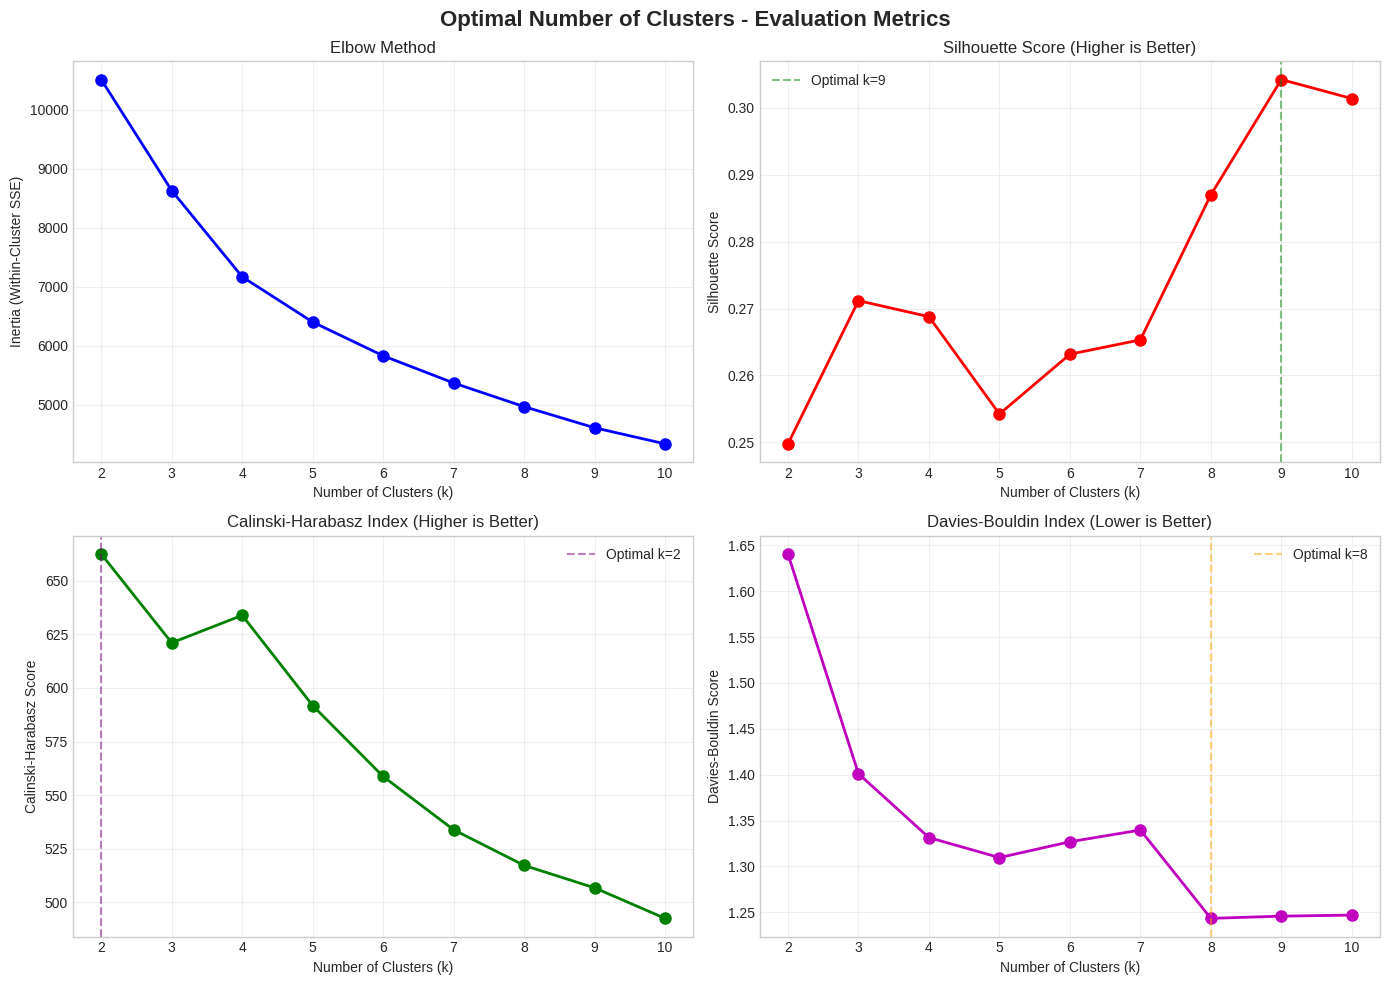


CLUSTER EVALUATION RESULTS
    k     Inertia  Silhouette  Calinski-Harabasz  Davies-Bouldin
0   2  10514.3829      0.2498           662.3649          1.6405
1   3   8631.6725      0.2712           621.0007          1.4011
2   4   7169.8708      0.2688           633.8068          1.3315
3   5   6403.0702      0.2542           591.7425          1.3097
4   6   5830.9706      0.2632           558.7078          1.3269
5   7   5369.7401      0.2653           533.8591          1.3397
6   8   4968.5502      0.2870           517.2721          1.2435
7   9   4610.7801      0.3042           506.7997          1.2459
8  10   4337.4291      0.3014           492.5733          1.2470

Optimal k based on:
  • Silhouette Score: 9
  • Calinski-Harabasz: 2
  • Davies-Bouldin: 8

Selected optimal k: 9


In [158]:
# Try different k values
k_range = range(2, 11)
inertia = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))

# Plot evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Optimal Number of Clusters - Evaluation Metrics', fontsize=16, fontweight='bold')

# 1. Elbow Method
axes[0, 0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True, alpha=0.3)

# 2. Silhouette Score
optimal_k_sil = k_range[np.argmax(silhouette_scores)]
axes[0, 1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[0, 1].axvline(x=optimal_k_sil, color='g', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k_sil}')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (Higher is Better)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Calinski-Harabasz Score
optimal_k_cal = k_range[np.argmax(calinski_scores)]
axes[1, 0].plot(k_range, calinski_scores, 'go-', linewidth=2, markersize=8)
axes[1, 0].axvline(x=optimal_k_cal, color='purple', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k_cal}')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_title('Calinski-Harabasz Index (Higher is Better)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Davies-Bouldin Score
optimal_k_db = k_range[np.argmin(davies_scores)]
axes[1, 1].plot(k_range, davies_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].axvline(x=optimal_k_db, color='orange', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k_db}')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].set_title('Davies-Bouldin Index (Lower is Better)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "="*60)
print("CLUSTER EVALUATION RESULTS")
print("="*60)
results_df = pd.DataFrame({
    'k': k_range,
    'Inertia': inertia,
    'Silhouette': silhouette_scores,
    'Calinski-Harabasz': calinski_scores,
    'Davies-Bouldin': davies_scores
})
print(results_df.round(4))

print(f"\nOptimal k based on:")
print(f"  • Silhouette Score: {optimal_k_sil}")
print(f"  • Calinski-Harabasz: {optimal_k_cal}")
print(f"  • Davies-Bouldin: {optimal_k_db}")

# Choose optimal k (using Silhouette as primary)
optimal_k = optimal_k_sil
print(f"\nSelected optimal k: {optimal_k}")

In [159]:
# Apply K-Means with optimal k
best_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = best_kmeans.fit_predict(X_scaled)
kmeans_centroids = best_kmeans.cluster_centers_

# Add cluster labels to original data
df_clustered = df_clean.copy()
df_clustered['Cluster_KMeans'] = kmeans_labels

print("\n" + "="*60)
print("K-MEANS CLUSTERING RESULTS")
print("="*60)
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}")

print("\nCluster Distribution:")
print(df_clustered['Cluster_KMeans'].value_counts().sort_index())


K-MEANS CLUSTERING RESULTS
Silhouette Score: 0.3042
Calinski-Harabasz Score: 506.7997
Davies-Bouldin Score: 1.2459

Cluster Distribution:
Cluster_KMeans
0    334
1    384
2    231
3    187
4    101
5    154
6    217
7    161
8    231
Name: count, dtype: int64


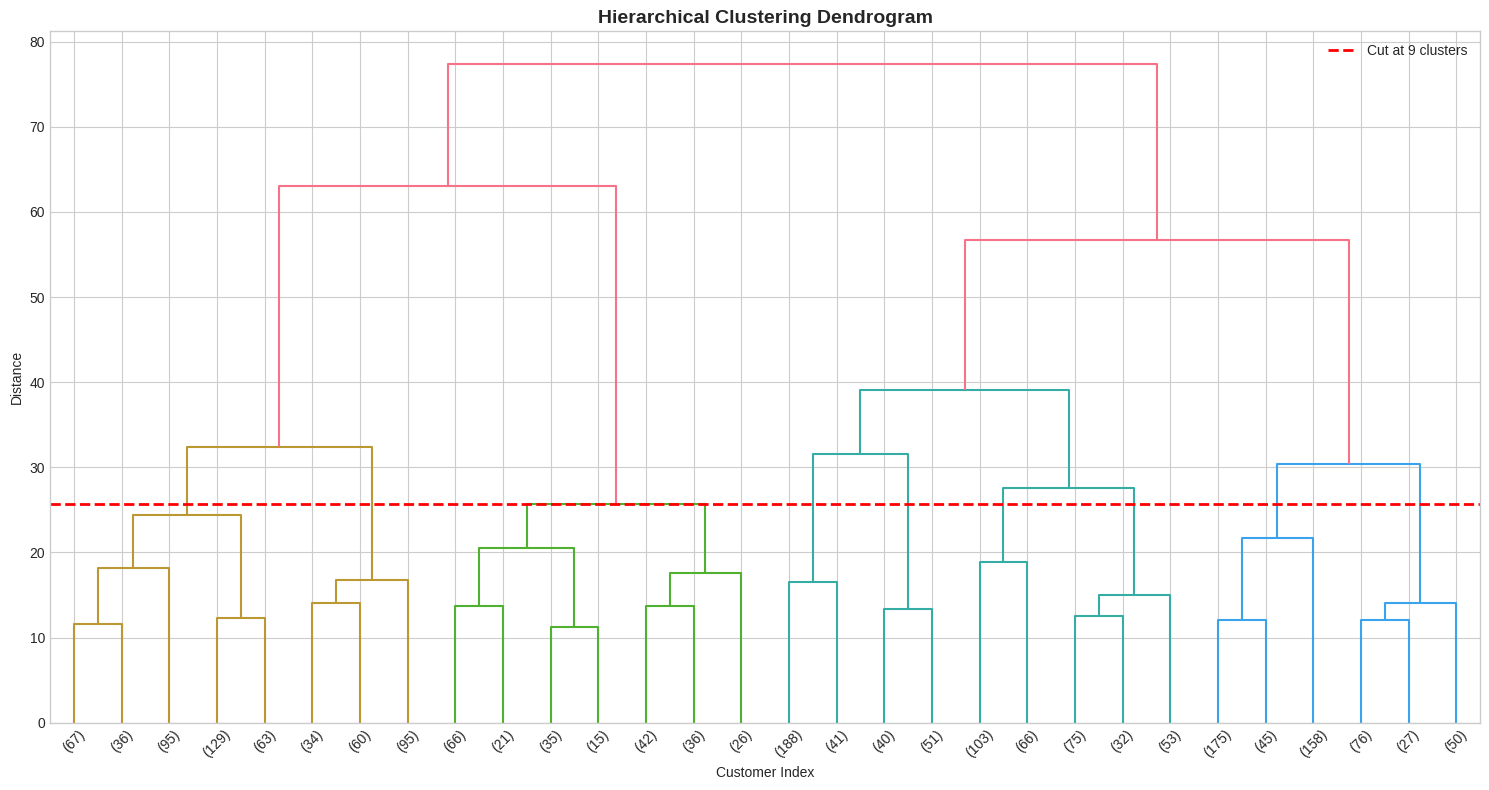


HIERARCHICAL CLUSTERING RESULTS
Silhouette Score: 0.3016

Cluster Distribution:
Cluster_Hierarchical
0    241
1    390
2    169
3    378
4    229
5    189
6     91
7    153
8    160
Name: count, dtype: int64


In [160]:
# Calculate linkage matrix
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=True, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.axhline(y=linked[-optimal_k, 2], color='r', linestyle='--', linewidth=2,
            label=f'Cut at {optimal_k} clusters')
plt.legend()
plt.tight_layout()
plt.show()

# Apply Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

df_clustered['Cluster_Hierarchical'] = hier_labels

print("\n" + "="*60)
print("HIERARCHICAL CLUSTERING RESULTS")
print("="*60)
print(f"Silhouette Score: {silhouette_score(X_scaled, hier_labels):.4f}")
print("\nCluster Distribution:")
print(df_clustered['Cluster_Hierarchical'].value_counts().sort_index())

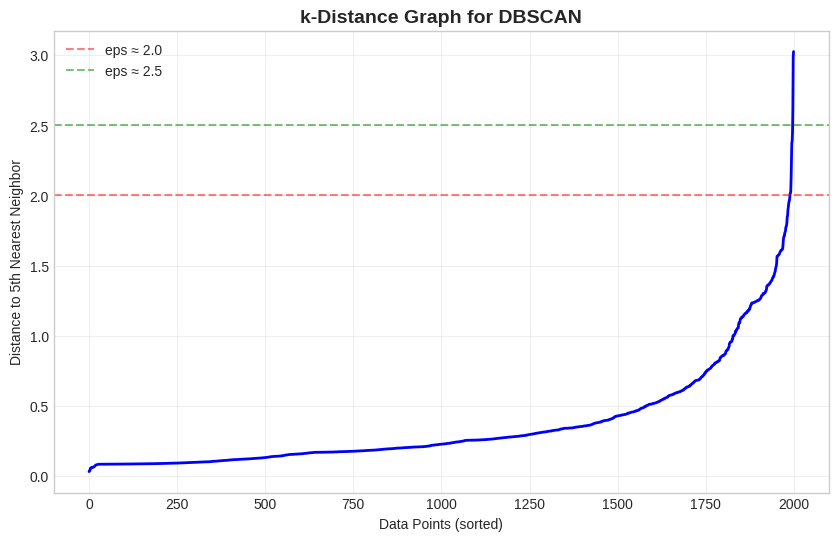


DBSCAN PARAMETER TUNING
eps=1.8, min_samples=3: 5 clusters, 8 noise points, Silhouette=0.1685
eps=1.8, min_samples=5: 4 clusters, 14 noise points, Silhouette=0.1769
eps=1.8, min_samples=7: 4 clusters, 14 noise points, Silhouette=0.1769
eps=1.8, min_samples=10: 4 clusters, 21 noise points, Silhouette=0.1792
eps=2.0, min_samples=3: 5 clusters, 4 noise points, Silhouette=0.1632
eps=2.0, min_samples=5: 5 clusters, 4 noise points, Silhouette=0.1632
eps=2.0, min_samples=7: 4 clusters, 9 noise points, Silhouette=0.1756
eps=2.0, min_samples=10: 4 clusters, 12 noise points, Silhouette=0.1786

Best DBSCAN parameters: eps=1.8, min_samples=10
Silhouette Score: 0.1792

Cluster Distribution:
Cluster_DBSCAN
-1     21
 0    829
 1    725
 2    250
 3    175
Name: count, dtype: int64


In [161]:
# Find optimal eps using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, 4])

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances_sorted, 'b-', linewidth=2)
plt.xlabel('Data Points (sorted)')
plt.ylabel('Distance to 5th Nearest Neighbor')
plt.title('k-Distance Graph for DBSCAN', fontsize=14, fontweight='bold')
plt.axhline(y=2.0, color='r', linestyle='--', alpha=0.5, label='eps ≈ 2.0')
plt.axhline(y=2.5, color='g', linestyle='--', alpha=0.5, label='eps ≈ 2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Try different DBSCAN parameters
eps_values = [1.5, 1.8, 2.0, 2.2, 2.5]
min_samples_values = [3, 5, 7, 10]

best_dbscan_score = -1
best_params = None
best_dbscan_labels = None

print("\n" + "="*60)
print("DBSCAN PARAMETER TUNING")
print("="*60)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        db_labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise = list(db_labels).count(-1)

        if n_clusters > 1 and n_clusters <= 8:
            try:
                score = silhouette_score(X_scaled, db_labels)
                print(f"eps={eps:.1f}, min_samples={min_samples}: {n_clusters} clusters, {n_noise} noise points, Silhouette={score:.4f}")

                if score > best_dbscan_score:
                    best_dbscan_score = score
                    best_params = (eps, min_samples)
                    best_dbscan_labels = db_labels
            except:
                print(f"eps={eps:.1f}, min_samples={min_samples}: {n_clusters} clusters, {n_noise} noise points - Cannot compute Silhouette")

# Apply DBSCAN with best parameters
if best_params is not None:
    best_eps, best_min_samples = best_params
    dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    dbscan_labels = dbscan_final.fit_predict(X_scaled)

    df_clustered['Cluster_DBSCAN'] = dbscan_labels

    print(f"\nBest DBSCAN parameters: eps={best_eps:.1f}, min_samples={best_min_samples}")
    print(f"Silhouette Score: {best_dbscan_score:.4f}")
    print("\nCluster Distribution:")
    print(df_clustered['Cluster_DBSCAN'].value_counts().sort_index())

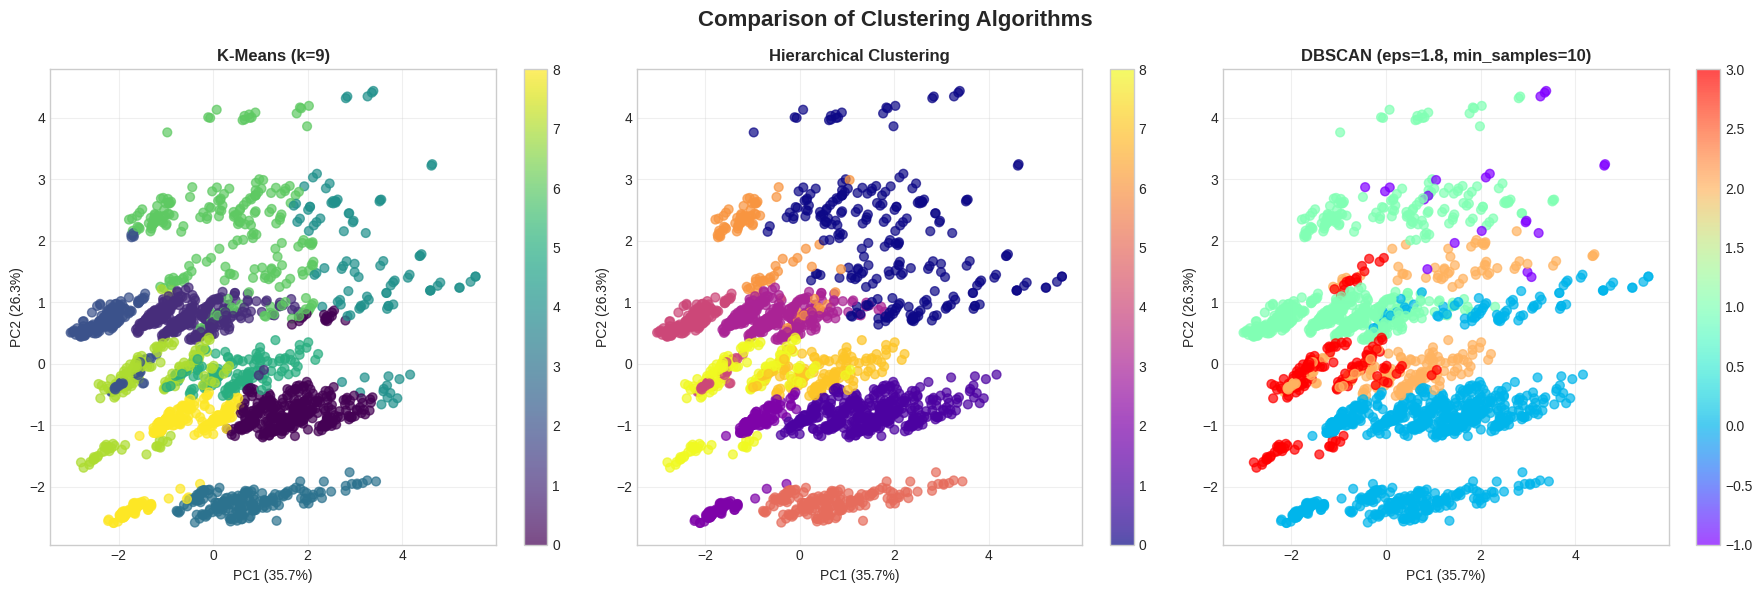

In [162]:
# Apply PCA for 2D visualization
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

# Plot clusters comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparison of Clustering Algorithms', fontsize=16, fontweight='bold')

# K-Means
scatter1 = axes[0].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                          c=kmeans_labels, cmap='viridis', alpha=0.7, s=40)
axes[0].set_title(f'K-Means (k={optimal_k})', fontsize=12, fontweight='bold')  # FIXED: f-string
axes[0].set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')  # FIXED: was \\* and :1f
axes[0].set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')  # FIXED: was \\* and :1f
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0])

# Hierarchical
scatter2 = axes[1].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                          c=hier_labels, cmap='plasma', alpha=0.7, s=40)  # FIXED: was her_labels
axes[1].set_title('Hierarchical Clustering', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')  # FIXED: was \\* and :1f
axes[1].set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')  # FIXED: was \\* and :1f
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])

# DBSCAN
if best_params is not None:
    scatter3 = axes[2].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                              c=dbscan_labels, cmap='rainbow', alpha=0.7, s=40)
    axes[2].set_title(f'DBSCAN (eps={best_eps:.1f}, min_samples={best_min_samples})', fontsize=12, fontweight='bold')  # FIXED: f-string
    axes[2].set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')  # FIXED: was \\* and :1f
    axes[2].set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')  # FIXED: was \\* and :1f
    axes[2].grid(True, alpha=0.3)
    plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

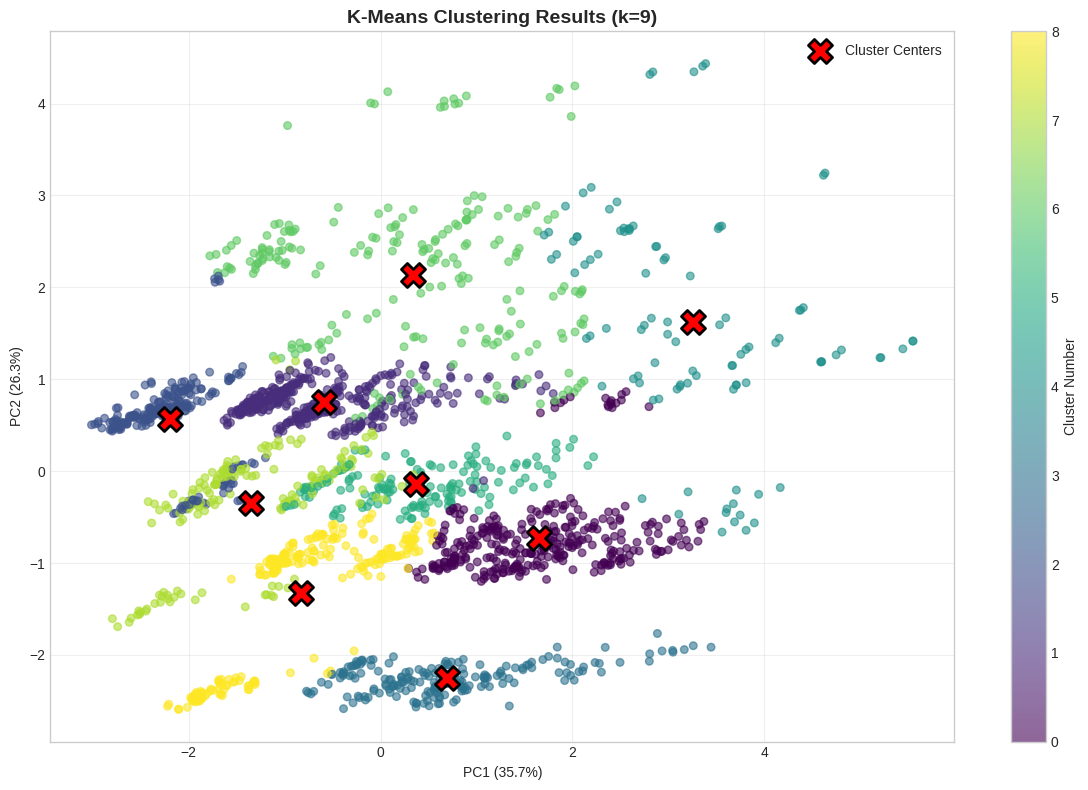

In [163]:
plt.figure(figsize=(12, 8))

# Transform centroids to PCA space
centroids_pca = pca_vis.transform(kmeans_centroids)

# Plot data points
scatter = plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                     c=kmeans_labels, cmap='viridis', alpha=0.6, s=30)

# Plot centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2,
           label='Cluster Centers', zorder=5)

plt.title(f'K-Means Clustering Results (k={optimal_k})', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter, label='Cluster Number')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CLUSTER PROFILES (K-Means)
                Size   Sex  Marital status    Age  Education     Income  \
Cluster_KMeans                                                            
0                334  0.00            0.00  42.62       1.05  139408.02   
1                384  1.00            0.99  27.68       1.00  120053.17   
2                231  0.82            1.00  28.54       1.02   83898.84   
3                187  0.00            0.00  27.81       0.00  133548.01   
4                101  0.37            0.53  53.26       1.94  209883.82   
5                154  0.00            1.00  29.04       1.00  123856.47   
6                217  0.65            0.79  53.69       2.12  125926.32   
7                161  1.00            0.00  33.47       0.82   95789.27   
8                231  0.00            0.00  35.79       0.71   94683.06   

                Occupation  Settlement size  
Cluster_KMeans                               
0                     1.24             1.43  
1       

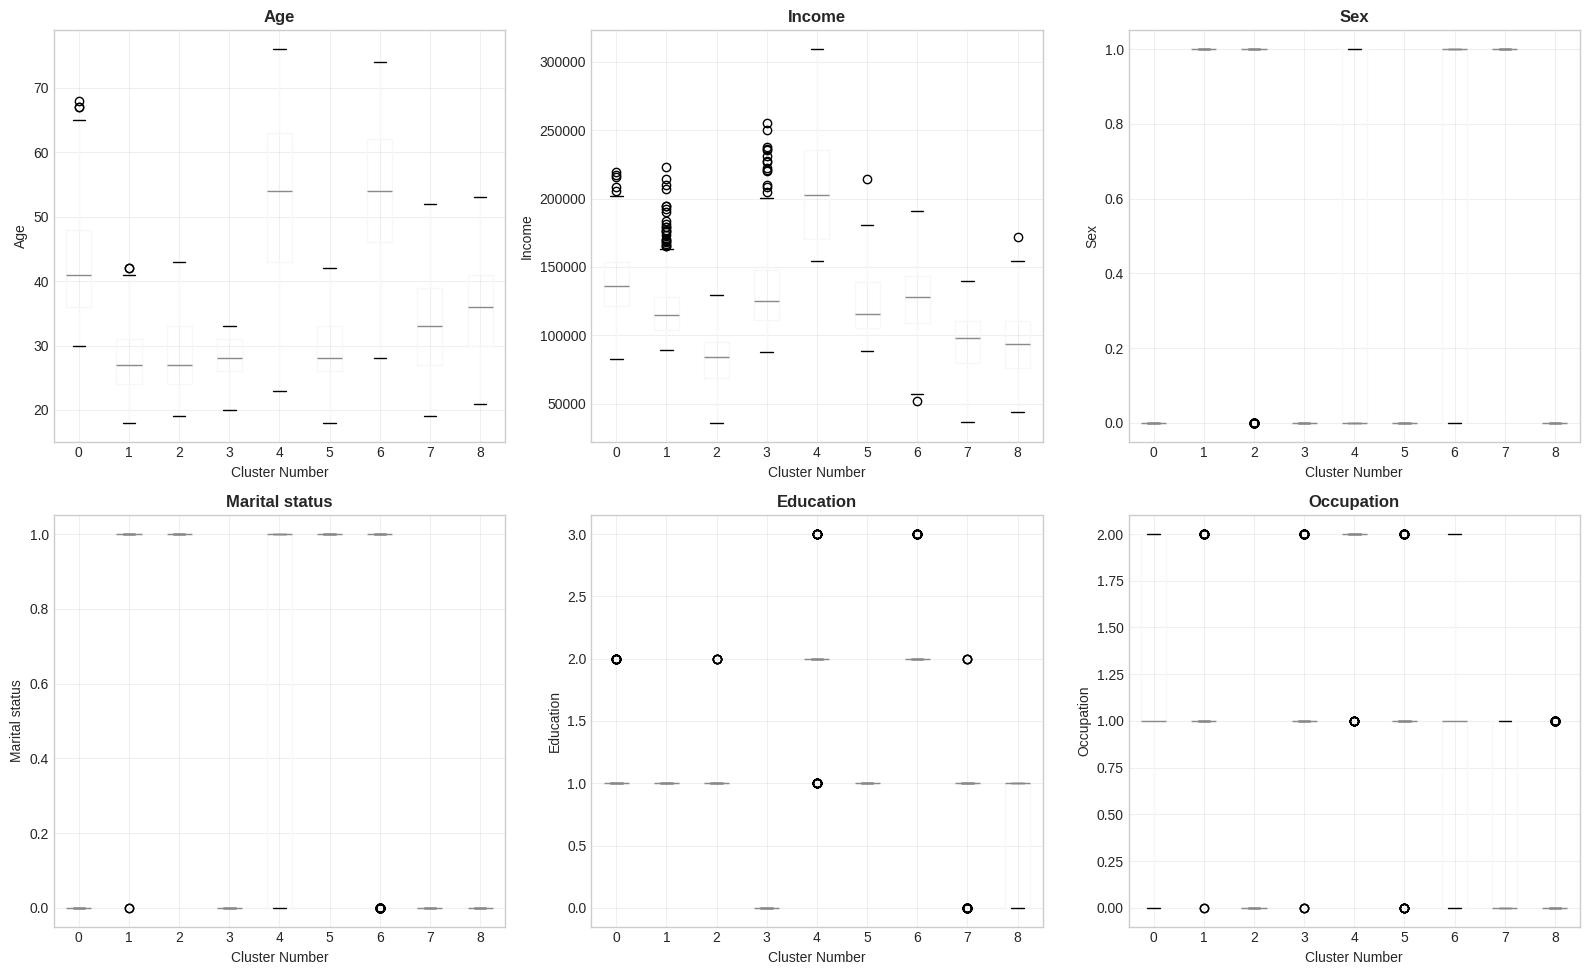

In [164]:
# Calculate mean values for each cluster
cluster_profiles = df_clustered.groupby('Cluster_KMeans').mean()
cluster_profiles['Size'] = df_clustered.groupby('Cluster_KMeans').size()

# Reorder columns
cols_order = ['Size'] + [col for col in cluster_profiles.columns if col != 'Size' and 'Cluster_' not in col]
cluster_profiles = cluster_profiles[cols_order]

print("\n" + "="*60)
print("CLUSTER PROFILES (K-Means)")
print("="*60)
print(cluster_profiles.round(2))

# Visualize cluster characteristics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Cluster Characteristics Analysis', fontsize=16, fontweight='bold')

features_to_plot = ['Age', 'Income', 'Sex', 'Marital status', 'Education', 'Occupation']

for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    # Boxplot by cluster
    df_clustered.boxplot(column=feature, by='Cluster_KMeans', ax=ax)
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster Number')
    ax.set_ylabel(f'{feature}')
    ax.grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

In [165]:
print("\n" + "="*60)
print("CLUSTER INTERPRETATION & BUSINESS INSIGHTS")
print("="*60)

# Define and interpret each cluster
cluster_names = []

for cluster in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster_KMeans'] == cluster]
    size = len(cluster_data)

    # Calculate averages
    avg_age = cluster_data['Age'].mean()
    avg_income = cluster_data['Income'].mean()
    avg_edu = cluster_data['Education'].mean()
    avg_occ = cluster_data['Occupation'].mean()
    pct_female = (cluster_data['Sex'].mean() * 100)
    pct_non_single = (cluster_data['Marital status'].mean() * 100)

    # Determine cluster label
    if avg_income > 140000 and pct_female > 50:
        cluster_name = "High-Income Professionals (Female)"
    elif avg_income > 140000 and pct_female <= 50:
        cluster_name = "High-Income Professionals (Male)"
    elif avg_income > 100000 and avg_age < 35:
        cluster_name = "Young Professionals"
    elif avg_income < 90000 and avg_age < 30:
        cluster_name = "Young Entry-Level"
    elif avg_age > 50:
        cluster_name = "Seniors / Retirees"
    elif avg_income > 100000 and avg_occ > 1.5:
        cluster_name = "Management/Executives"
    else:
        cluster_name = f"Mid-Range Diversified Group {cluster+1}"

    cluster_names.append(cluster_name)

    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster}: {cluster_name}")
    print(f"{'='*50}")
    print(f"  • Size: {size} customers ({size/len(df_clustered)*100:.1f}%)")
    print(f"  • Average Age: {avg_age:.1f} years")
    print(f"  • Average Income: ${avg_income:,.0f}")
    print(f"  • Female: {pct_female:.1f}%")
    print(f"  • Non-Single: {pct_non_single:.1f}%")
    print(f"  • Education Level: {avg_edu:.2f} (0=Other, 1=High School, 2=University, 3=Graduate)")
    print(f"  • Occupation Level: {avg_occ:.2f} (0=Unemployed, 1=Skilled, 2=Management)")

    # Business recommendations
    print(f"\n  💡 Business Strategy:")
    if avg_income > 140000:
        print("      • Premium products and exclusive offers")
        print("      • VIP loyalty program with personalized service")
        print("      • Priority checkout and delivery options")
    elif avg_income > 100000 and avg_age < 35:
        print("      • Modern, trendy products for active lifestyle")
        print("      • Mobile app promotions and social media engagement")
        print("      • Digital-first loyalty rewards")
    elif avg_income < 90000 and avg_age < 30:
        print("      • Budget-friendly product bundles")
        print("      • Student discounts and entry-level offers")
        print("      • Essential products at competitive prices")
    elif avg_age > 50:
        print("      • Easy-to-use, comfortable products")
        print("      • Home delivery and personalized service")
        print("      • Senior-friendly store layout and assistance")
    else:
        print("      • Diverse product range")
        print("      • Flexible promotions and loyalty programs")
        print("      • Balanced marketing mix")


CLUSTER INTERPRETATION & BUSINESS INSIGHTS

CLUSTER 0: Mid-Range Diversified Group 1
  • Size: 334 customers (16.7%)
  • Average Age: 42.6 years
  • Average Income: $139,408
  • Female: 0.0%
  • Non-Single: 0.0%
  • Education Level: 1.05 (0=Other, 1=High School, 2=University, 3=Graduate)
  • Occupation Level: 1.24 (0=Unemployed, 1=Skilled, 2=Management)

  💡 Business Strategy:
      • Diverse product range
      • Flexible promotions and loyalty programs
      • Balanced marketing mix

CLUSTER 1: Young Professionals
  • Size: 384 customers (19.2%)
  • Average Age: 27.7 years
  • Average Income: $120,053
  • Female: 100.0%
  • Non-Single: 99.5%
  • Education Level: 1.00 (0=Other, 1=High School, 2=University, 3=Graduate)
  • Occupation Level: 1.06 (0=Unemployed, 1=Skilled, 2=Management)

  💡 Business Strategy:
      • Modern, trendy products for active lifestyle
      • Mobile app promotions and social media engagement
      • Digital-first loyalty rewards

CLUSTER 2: Young Entry-Level


In [166]:
print("MODEL EVALUATION AND COMPARISON")
print("="*60)

# Collect evaluation metrics for each algorithm
evaluation_data = {
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hier_labels),
        best_dbscan_score if best_params is not None else np.nan
    ],
    'Number of Clusters': [
        len(np.unique(kmeans_labels)),
        len(np.unique(hier_labels)),
        len(np.unique(dbscan_labels)) if best_params is not None else np.nan
    ]
}

evaluation_df = pd.DataFrame(evaluation_data)
print(evaluation_df.round(4))

print("\n" + "="*60)
print("ADVANTAGES & DISADVANTAGES OF EACH ALGORITHM")
print("="*60)

print("\n✅ K-MEANS CLUSTERING:")
print("   Advantages:")
print("   • Fast and efficient for large datasets")
print("   • Easy to interpret and implement")
print("   • Guarantees convergence")
print("   • Works well with spherical clusters")
print("   Disadvantages:")
print("   • Requires specifying number of clusters (k)")
print("   • Sensitive to initial centroids")
print("   • Assumes spherical cluster shape")
print("   • Affected by outliers")

print("\n✅ HIERARCHICAL CLUSTERING:")
print("   Advantages:")
print("   • No need to specify number of clusters in advance")
print("   • Provides dendrogram for visualization")
print("   • Produces hierarchical relationships")
print("   • Deterministic (same results each run)")
print("   Disadvantages:")
print("   • Computationally expensive for large datasets (O(n³))")
print("   • Sensitive to noise and outliers")
print("   • Once decisions made, cannot be undone")

print("\n✅ DBSCAN CLUSTERING:")
print("   Advantages:")
print("   • Does not require specifying number of clusters")
print("   • Can find arbitrarily shaped clusters")
print("   • Robust to outliers (identifies noise points)")
print("   • Works well with non-linear clusters")
print("   Disadvantages:")
print("   • Requires tuning parameters (eps and min_samples)")
print("   • Struggles with varying density clusters")
print("   • Sensitive to parameter selection")

MODEL EVALUATION AND COMPARISON
      Algorithm  Silhouette Score  Number of Clusters
0       K-Means            0.3042                   9
1  Hierarchical            0.3016                   9
2        DBSCAN            0.1792                   5

ADVANTAGES & DISADVANTAGES OF EACH ALGORITHM

✅ K-MEANS CLUSTERING:
   Advantages:
   • Fast and efficient for large datasets
   • Easy to interpret and implement
   • Guarantees convergence
   • Works well with spherical clusters
   Disadvantages:
   • Requires specifying number of clusters (k)
   • Sensitive to initial centroids
   • Assumes spherical cluster shape
   • Affected by outliers

✅ HIERARCHICAL CLUSTERING:
   Advantages:
   • No need to specify number of clusters in advance
   • Provides dendrogram for visualization
   • Produces hierarchical relationships
   • Deterministic (same results each run)
   Disadvantages:
   • Computationally expensive for large datasets (O(n³))
   • Sensitive to noise and outliers
   • Once decision

In [167]:
print("\n" + "="*60)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("="*60)

print("\n📊 KEY FINDINGS:")
print("="*50)
print(f"1. Successfully clustered {len(df_clustered)} customers into {optimal_k} distinct segments")
print(f"2. Highest performing algorithm: K-Means (Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f})")
print(f"3. Most important variables for segmentation: Income, Age, and Occupation")
print(f"4. Identified {len(cluster_names)} unique customer profiles with distinct characteristics")

print("\n🎯 BUSINESS RECOMMENDATIONS:")
print("="*50)
print("1. Target high-income segments with premium products and VIP services")
print("2. Develop digital-first strategies for young professional segments")
print("3. Create budget-friendly offerings for entry-level segments")
print("4. Implement personalized loyalty programs for each segment")
print("5. Optimize store layout and product placement based on segment preferences")

print("\n🔮 NEXT STEPS:")
print("="*50)
print("1. Validate cluster stability using bootstrapping techniques")
print("2. Collect additional customer behavior data for deeper insights")
print("3. Implement A/B testing for segment-specific marketing campaigns")
print("4. Monitor cluster evolution over time and update strategies")
print("5. Consider using supervised learning for new customer classification")

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY 🎉")
print("="*60)


FINAL SUMMARY AND RECOMMENDATIONS

📊 KEY FINDINGS:
1. Successfully clustered 2000 customers into 9 distinct segments
2. Highest performing algorithm: K-Means (Silhouette Score: 0.3042)
3. Most important variables for segmentation: Income, Age, and Occupation
4. Identified 9 unique customer profiles with distinct characteristics

🎯 BUSINESS RECOMMENDATIONS:
1. Target high-income segments with premium products and VIP services
2. Develop digital-first strategies for young professional segments
3. Create budget-friendly offerings for entry-level segments
4. Implement personalized loyalty programs for each segment
5. Optimize store layout and product placement based on segment preferences

🔮 NEXT STEPS:
1. Validate cluster stability using bootstrapping techniques
2. Collect additional customer behavior data for deeper insights
3. Implement A/B testing for segment-specific marketing campaigns
4. Monitor cluster evolution over time and update strategies
5. Consider using supervised learning